In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Daily Challenge: Breast Cancer Prediction

### Exploratory Data Analysis

In [3]:
# Load dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/BootGenAI/breastCancer.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
#check and handle missing values
df.info()
# or
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [5]:
# drop unnecessary column
df = df.drop(columns=['id', 'Unnamed: 32'])

/tmp/ipython-input-412871634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


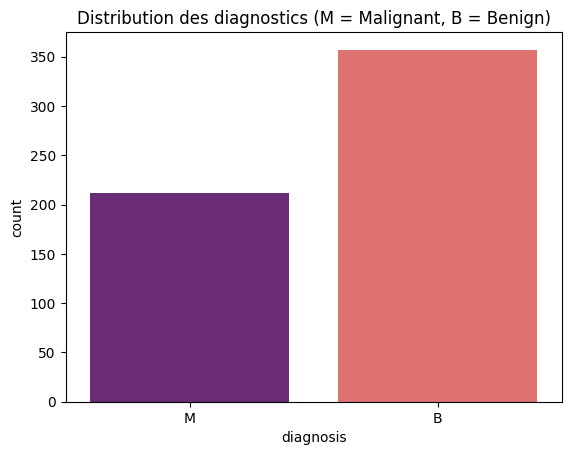

In [6]:
# create a countplot (display diagnosis)
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot pour la variable cible 'diagnosis'
sns.countplot(x='diagnosis', data=df, palette='magma')

# Ajouter un titre
plt.title("Distribution des diagnostics (M = Malignant, B = Benign)")

# Afficher le graphique
plt.show()


### Data Preprocessing, Building models and Evaluation

In [7]:
#count of unique rows (diagnosis)
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [8]:
#map categorical values to num
df["diagnosis"] = df["diagnosis"].map({"M" : 1 , "B" : 0})

#verify
print(df["diagnosis"].unique())
print(df["diagnosis"].value_counts())

[1 0]
diagnosis
0    357
1    212
Name: count, dtype: int64


In [9]:
#Split the data train test
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y            # garder la proportion B/M équilibrée
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (455, 30) (455,)
Test shape: (114, 30) (114,)


In [15]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9385964912280702


In [16]:
#K nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5) # k=5 par défaut
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.9122807017543859


In [17]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)


Random Forest Accuracy: 0.9736842105263158


In [18]:
#SVM
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.9210526315789473


Among the models I implemented (Logistic Regression, KNN, Random Forest, SVM), the Random Forest classifier achieved the highest accuracy, making it the best model for this dataset.